# Goodbook Recommendations

In [1]:
# Install the LibRecommender package
# !pip install -U LibRecommender

# added by uv package manager

In [9]:
# Import packages and configure notebook
import pandas as pd
import libreco.data
import libreco.algorithms 
from libreco.evaluation import evaluate

pd.options.display.max_rows = 99
pd.options.display.max_columns = 99

%matplotlib inline

## Reading the data

This assumes the files are located in "data" folder in the folder where the notebook is

In [10]:
# Reading the ratings and book files into pandas DataFrames

df_books = pd.read_csv("data/books.csv")
df_ratings = pd.read_csv('data/ratings.csv')

df_ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


Data is loaded, ready to do some Exploratory Data Analysis...

## Exploratory Data Analysis

### Ratings

In [40]:
df_ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [32]:
df_ratings.info()
desc_ratings = df_ratings.describe().T
desc_ratings.style.format({
    "count": "{:,.0f}",
    "mean": "{:,.0f}",
    "std": "{:,.0f}",
    "min": "{:,.0f}",
    "25%": "{:,.0f}",
    "50%": "{:,.0f}",
    "75%": "{:,.0f}",
    "max": "{:,.0f}",
})


<class 'pandas.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


,count,mean,std,min,25%,50%,75%,max
user_id,"5,976,479","26,224","15,413",1,"12,813","25,938","39,509","53,424"
book_id,"5,976,479","2,006","2,468",1,198,885,"2,973","10,000"
rating,"5,976,479",4,1,1,3,4,5,5


<Axes: >

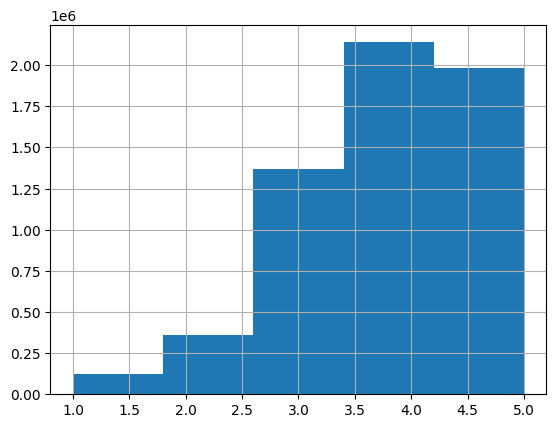

In [26]:
df_ratings['rating'].hist(bins=5)

### Books

In [41]:
df_books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [36]:
desc_books = df_books.describe().T
desc_books.style.format({
    "count": "{:,.0f}",
    "mean": "{:,.0f}",
    "std": "{:,.0f}",
    "min": "{:,.0f}",
    "25%": "{:,.0f}",
    "50%": "{:,.0f}",
    "75%": "{:,.0f}",
    "max": "{:,.0f}",
})

,count,mean,std,min,25%,50%,75%,max
book_id,"10,000","5,000","2,887",1,"2,501","5,000","7,500","10,000"
goodreads_book_id,"10,000","5,264,697","7,575,462",1,"46,276","394,966","9,382,225","33,288,638"
best_book_id,"10,000","5,471,214","7,827,330",1,"47,912","425,124","9,636,112","35,534,230"
work_id,"10,000","8,646,183","11,751,061",87,"1,008,841","2,719,524","14,517,748","56,399,597"
books_count,"10,000",76,170,1,23,40,67,"3,455"
isbn13,"9,415","9,755,044,298,883","442,861,920,666","195,170,342","9,780,316,192,995","9,780,451,528,640","9,780,830,777,175","9,790,007,672,390"
original_publication_year,"9,979","1,982",153,"-1,750","1,990","2,004","2,011","2,017"
average_rating,"10,000",4,0,2,4,4,4,5
ratings_count,"10,000","54,001","157,370","2,716","13,569","21,156","41,054","4,780,653"
work_ratings_count,"10,000","59,687","167,804","5,510","15,439","23,832","45,915","4,942,365"


In [39]:
unique_book_ids = df_ratings["book_id"].unique()
print(f"Number of unique book IDs in ratings: {len(unique_book_ids)}")

Number of unique book IDs in ratings: 10000


In [43]:
# Compare work_ratings_count with the sum of ratings_1 ... ratings_5
ratings_cols = ["ratings_1", "ratings_2", "ratings_3", "ratings_4", "ratings_5"]

comparison = df_books[["book_id", "work_ratings_count"] + ratings_cols].copy()
comparison["ratings_sum"] = comparison[ratings_cols].sum(axis=1)
comparison["diff"] = comparison["work_ratings_count"] - comparison["ratings_sum"]
comparison["abs_diff"] = comparison["diff"].abs()

print("Summary of differences:")
print(comparison["diff"].describe())

exact_matches = (comparison["diff"] == 0).sum()
print(f"\nExact matches: {exact_matches}/{len(comparison)} ({exact_matches/len(comparison):.2%})")

Summary of differences:
count    10000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: diff, dtype: float64

Exact matches: 10000/10000 (100.00%)


In [47]:
# Compare rating counts and average rating in books vs ratings dataframe

# Calculate actual average rating and count from df_ratings
ratings_summary = df_ratings.groupby("book_id")["rating"].agg(
    fromratings_avg_rating="mean",
    fromratings_rating_count="count"
).reset_index()

# Merge with books dataframe
comparison_ratings = df_books[["book_id", "average_rating", "ratings_count"]].merge(
    ratings_summary, on="book_id", how="left"
)

comparison_ratings["avg_rating_diff"] = comparison_ratings["average_rating"] - comparison_ratings["fromratings_avg_rating"]
comparison_ratings["rating_count_diff"] = comparison_ratings["ratings_count"] - comparison_ratings["fromratings_rating_count"]

print("Average rating difference (books vs ratings):")
print(comparison_ratings["avg_rating_diff"].describe())
print("\nRating count difference (books vs ratings):")
print(comparison_ratings["rating_count_diff"].describe().apply("{:,.0f}".format))

comparison_ratings.head(10).style.format({
    "average_rating": "{:.2f}",
    "fromratings_avg_rating": "{:.2f}",
    "avg_rating_diff": "{:.2f}",
})

Average rating difference (books vs ratings):
count    10000.000000
mean         0.099055
std          0.096535
min         -0.511923
25%          0.039798
50%          0.091734
75%          0.150667
max          0.926667
Name: avg_rating_diff, dtype: float64

Rating count difference (books vs ratings):
count       10,000
mean        53,404
std        156,187
min          2,615
25%         13,395
50%         20,913
75%         40,572
max      4,757,847
Name: rating_count_diff, dtype: str


,book_id,average_rating,ratings_count,fromratings_avg_rating,fromratings_rating_count,avg_rating_diff,rating_count_diff
0,1,4.34,4780653,4.28,22806,0.06,4757847
1,2,4.44,4602479,4.35,21850,0.09,4580629
2,3,3.57,3866839,3.21,16931,0.36,3849908
3,4,4.25,3198671,4.33,19088,-0.08,3179583
4,5,3.89,2683664,3.77,16604,0.12,2667060
5,6,4.26,2346404,4.19,11264,0.07,2335140
6,7,4.25,2071616,4.15,15558,0.10,2056058
7,8,3.79,2044241,3.71,14472,0.08,2029769
8,9,3.85,2001311,3.60,13451,0.25,1987860
9,10,4.24,2035490,4.19,13445,0.05,2022045


In [48]:
# Show top 5 records with maximum rating count difference
top_5_max_diff = comparison_ratings.nlargest(5, 'rating_count_diff')
top_5_max_diff

,book_id,average_rating,ratings_count,fromratings_avg_rating,fromratings_rating_count,avg_rating_diff,rating_count_diff
0,1,4.34,4780653,4.279707,22806,0.060293,4757847
1,2,4.44,4602479,4.351350,21850,0.088650,4580629
2,3,3.57,3866839,3.214341,16931,0.355659,3849908
3,4,4.25,3198671,4.329369,19088,-0.079369,3179583
4,5,3.89,2683664,3.772224,16604,0.117776,2667060


#### Observations based on the EDA

- The ratings dataset contains **5,976,479** ratings from **53,424** users on **10,000** books, with an average rating of **3.92** and ratings ranging from 1 to 5.
- The books dataset contains **10,000** books with an average rating of **4.00** and a standard deviation of **0.25**, suggesting most books are rated positively.
- The work_ratings_count in the books dataset exactly matches the sum of ratings_1 through ratings_5 for all 10,000 books (zero differences).
- The ratings_count in the books dataset is significantly higher than the count in the ratings dataset (e.g., book 1 has 4,780,653 vs 22,806), suggesting the ratings dataset is a **sample** of the full Goodreads dataset.
- The average ratings in the books dataset are slightly higher than those computed from the ratings sample, likely due to the sampling bias in the ratings dataset.
- The histogram of df_ratings['rating'] (5 bins) shows a clear concentration in the higher ratings (**4–5**), while low ratings (**1–2**) are comparatively rare.
- This indicates a left-skewed / positive-feedback bias in user behavior, where users tend to rate books they liked.
- As a result, recommendation models may be better at distinguishing among liked books than predicting strong dislikes, so metrics should be interpreted with this class imbalance in mind.

## Recommendations with LibRecommender package

[LibRecommender Documentation](https://librecommender.readthedocs.io/en/latest/index.html)

LibRecommender expects our columns to be named `user`, `item`, and `label`, so we need to rename the colums in `df_ratings`, [see documentation](https://librecommender.readthedocs.io/en/latest/user_guide/data_processing.html#data-processing)

In [49]:
# Modified the data frame name to keep original df_ratings for comparison and renamed columns to match LibRecommender's expected format
df_named = df_ratings.rename(
    columns={"user_id": "user", "book_id": "item", "rating": "label"},
    inplace=False
)
df_named.head()

,user,item,label
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


### Train and test dataset

The next step is to create a train (and test) set from the data for a recommender model,

e.g. using `libreco.data.random_split` [(see documentation)](https://librecommender.readthedocs.io/en/latest/api/data/split.html#libreco.data.random_split)


For more possibilities see https://librecommender.readthedocs.io/en/latest/api/data/split.html

In [13]:
# Split the data into a train and test set (20%) randomly
df_train, df_test = libreco.data.random_split(df_named, test_size=0.2)
train_data, data_info = libreco.data.DatasetPure.build_trainset(df_train)
test_data = libreco.data.DatasetPure.build_evalset(df_test)

In [ ]:
# Split the data into a train and test set (20%) using split_by_ratio
df_train_ratio, df_test_ratio = libreco.data.split_by_ratio(df_named, test_size=0.2)
train_data_ratio, data_info_ratio = libreco.data.DatasetPure.build_trainset(df_train_ratio)
test_data_ratio = libreco.data.DatasetPure.build_evalset(df_test_ratio)

#### Comparison of alternative train - test splits

- **random_split(df_named, test_size=0.2)**  
    - Performs a **global random split** across all interactions.  
    - Simple and fast baseline.  
    - Can place many interactions of some users/items only in one split, which may increase cold-start effects in test.

- **split_by_ratio(df_named, test_size=0.2)**  
    - Performs a **ratio-based split at user level** (when possible), so users are more consistently represented in both train and test.  
    - Usually better aligned with recommendation evaluation, since the model is tested on users seen during training.  
    - Slightly more structured than pure global random splitting.

**In this notebook:** both methods use an **80/20 split**, then build LibRecommender datasets with DatasetPure.build_trainset(...) and DatasetPure.build_evalset(...).

**Practical takeaway:**  
Use random_split for a quick baseline; prefer split_by_ratio when you want a more reliable user-centered evaluation.

### Recommender algorithm

Now you should be ready to try one of the [recommender algorithms](https://librecommender.readthedocs.io/en/latest/api/algorithms/index.html) and [evaluate accuracy](https://librecommender.readthedocs.io/en/latest/user_guide/evaluation_save_load.html). Below you will find a function that implements precision and recall at k.


In [14]:
def precision_recall_at_k(df_test, k=10, threshold=3.5):
    """Calculate precision and recall at k metrics for each user"""

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in df_test.groupby("user"):

        # Number of relevant items
        n_rel = sum(user_ratings["label"] >= threshold)

        # Sort user ratings by estimated value
        topk = user_ratings.sort_values(by="pred", ascending=False).head(k)

        # Number of recommended items in top k
        n_rec_k = sum((topk["pred"] >= threshold))

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(
            ((topk["label"] >= threshold) & (topk["pred"] >= threshold))
        )

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. We here set it to 0.
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. We here set it to 0.
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        
    precision_at_k = sum(precisions.values())/len(precisions)
    recall_at_k = sum(recalls.values())/len(recalls)
    
    print(f'precision at {k}:\t{precision_at_k:0.4f}')
    print(f'recall at {k}.  :\t{recall_at_k:0.4f}')

    return precision_at_k, recall_at_k

### Training two recommender models, getting predictions, comparison of results

#### Item-based collaborative filtering using the random_split training data

In [15]:
# Train an Item-based Nearest neighbourhood model with 20 neighbours and using Cosine similarity as similarity measure
# shows the rmse on the test set
model = libreco.algorithms.ItemCF(data_info=data_info, task="rating", sim_type="cosine", k_sim=20)
model.fit(
    train_data, 
    neg_sampling=False,
    eval_data=test_data,
    metrics=["rmse"],
    verbose=10
)

Training start time: 2026-04-20 19:21:38
Final block size and num: (10000, 1)
sim_matrix elapsed: 2.602s
sim_matrix, shape: (10000, 10000), num_elements: 46903360, density: 46.9034 %


eval_pointwise:   1%|          | 1/146 [00:00<00:22,  6.44it/s]

No common interaction or similar neighbor for user 16171 and item 5561, proceed with default prediction
No common interaction or similar neighbor for user 25337 and item 585, proceed with default prediction
No common interaction or similar neighbor for user 33667 and item 2240, proceed with default prediction
No common interaction or similar neighbor for user 37168 and item 995, proceed with default prediction
No common interaction or similar neighbor for user 15755 and item 2115, proceed with default prediction
No common interaction or similar neighbor for user 8958 and item 1525, proceed with default prediction


eval_pointwise: 100%|██████████| 146/146 [00:21<00:00,  6.80it/s]


	 eval rmse: 1.0527


In [16]:
# get a prediction of the rating for user_id 1 on book_id 2
predicted_rating = model.predict(user=1, item=2)
predicted_rating

np.float64(4.286332607269287)

In [17]:
# predict ratings for the complete test set
df_test["pred"] = model.predict(df_test["user"], df_test["item"])
df_test

,user,item,label,pred
3623535,42562,2757,3,3.264647
3985638,43232,134,4,3.457814
2983642,37244,1463,5,4.082747
5812251,53366,71,2,3.192377
2208852,29634,3339,4,3.000000
...,...,...,...,...
5145558,36367,4488,5,5.000000
2509373,32720,233,5,4.515522
1806767,24663,805,5,4.194372
172718,4547,3100,4,4.692034


In [18]:
# calculate precision at recall at K over the test set
precision, recall = precision_recall_at_k(df_test)


precision at 10:	0.6530
recall at 10.  :	0.4332


#### User-based collaborative filtering using the random_split training data